# Notebook 01 — Data ingestion & quality audit

## Business question

Did a **simulated regional surge/incentive rollout** (high-volume Brazilian states after a policy cutoff) improve **on-time delivery**?

We cannot answer that in this notebook yet. First we need trustworthy **order-level data**: one row per order, valid delivery timestamps, and join keys that won't inflate row counts when we build the analytical mart.

## What this notebook does

| Phase | Goal | Status |
|-------|------|--------|
| 1 | Load raw Olist CSVs and audit table grain / keys | Done |
| 2 | Load tables into DuckDB (`data/olist.db`) | Done |
| 3 | Build `orders_analytical` (one row per `order_id`) | Done |
| 4 | Outcome EDA (supports DiD design) | Done |

**Primary outcomes (defined in the mart, not here yet):**
- `on_time` — delivered on or before estimated delivery date
- `delivery_days` — days from purchase to customer delivery
- `customer_state` — region for treated vs control groups

> Full schema and join rules: [`docs/DATA_MODEL.md`](../docs/DATA_MODEL.md)


## Notebook structure

1. **Setup & load** — imports, paths, read 9 CSVs
2. **`orders` audit** — dtypes, null logic, primary key, date range *(spine of the mart)*
3. **`order_items` audit** — fan-out check *(must aggregate before join)*
4. **`customers` audit** — join key to orders, state for regional analysis
5. **Next** — DuckDB load → `orders_analytical` → EDA

### Target mart grain

`orders_analytical`: **one row per `order_id`**

If we join `order_items` or `payments` without aggregating first, one order becomes many rows and every downstream metric (on-time rate, DiD) is wrong.

## 1. Setup & data load

Load all 9 Olist CSVs into pandas for inspection. We persist to DuckDB in a later section; this phase is about understanding grain and data quality before any joins.

In [22]:
import duckdb, pandas as pd 
from pathlib import Path
print("OK")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

OK


In [23]:

customers =pd.read_csv(ROOT / "data/raw/olist/olist_customers_dataset.csv")
orders = pd.read_csv(ROOT / "data/raw/olist/olist_orders_dataset.csv")
order_items = pd.read_csv(ROOT / "data/raw/olist/olist_order_items_dataset.csv")
payments = pd.read_csv(ROOT / "data/raw/olist/olist_order_payments_dataset.csv")
reviews = pd.read_csv(ROOT / "data/raw/olist/olist_order_reviews_dataset.csv")
products = pd.read_csv(ROOT / "data/raw/olist/olist_products_dataset.csv")
product_category_name_translation = pd.read_csv(ROOT / "data/raw/olist/product_category_name_translation.csv")
geolocation = pd.read_csv(ROOT / "data/raw/olist/olist_geolocation_dataset.csv")
sellers = pd.read_csv(ROOT / "data/raw/olist/olist_sellers_dataset.csv")








## 2. `orders` table audit

`orders` is the **spine** of our mart: one row per order. We check four things before building joins:

1. **Types** — timestamps must be datetime to compute `delivery_days`
2. **Nulls** — missing delivery dates should align with non-delivered status
3. **Primary key** — `order_id` must be unique (no fan-out from the spine itself)
4. **Date range** — confirms we have enough pre/post history for DiD

In [24]:

orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [25]:
print(orders.dtypes)


order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object


### 2a. Parse timestamps

**Why:** CSVs load date columns as strings. We need datetimes to compute `delivery_days` and compare delivery vs estimated dates.

In [26]:
time_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in time_cols: 
    orders[col] = pd.to_datetime(orders[col])

orders.dtypes




order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [27]:
print(orders.isnull().sum())
print(orders.shape)

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
(99441, 8)


### 2b. Null audit — delivery timestamp vs status

**Why:** `order_delivered_customer_date` drives our primary outcome (`on_time`). We need to know whether nulls mean "not delivered yet" (expected) or data errors (bad).

**Check:** Crosstab `order_status` × missing delivery timestamp.

In [28]:
orders['order_status'].unique()

<StringArray>
[  'delivered',    'invoiced',     'shipped',  'processing', 'unavailable',
    'canceled',     'created',    'approved']
Length: 8, dtype: str

*(Reference)* Distinct `order_status` values in the crosstab below:

In [29]:
# Null audit: order_delivered_customer_date vs order_status
missing_delivered_ts = orders["order_delivered_customer_date"].isna()

print("Crosstab (columns: False=has timestamp, True=missing)")
print(
    pd.crosstab(orders["order_status"], missing_delivered_ts, margins=True).to_string()
)


Crosstab (columns: False=has timestamp, True=missing)
order_delivered_customer_date  False  True    All
order_status                                     
approved                           0     2      2
canceled                           6   619    625
created                            0     5      5
delivered                      96470     8  96478
invoiced                           0   314    314
processing                         0   301    301
shipped                            0  1107   1107
unavailable                        0   609    609
All                            96476  2965  99441


#### So what — delivery timestamp nulls

- **2,965** null `order_delivered_customer_date`; almost all are **non-delivered** statuses (see crosstab).
- **8** delivered orders still have null timestamp (**~0.01%**) — treat as exceptions.

**Mart rule:** compute `delivery_days` / `on_time` only when `order_status == 'delivered'` and delivery timestamp is not null; otherwise NULL.

### 2c. Primary key check

**Why:** The mart must be one row per `order_id`. Duplicate `order_id` in `orders` would break every downstream metric.

In [30]:
print(orders['order_id'].duplicated().sum()) # expect 0 
print(orders['order_id'].nunique() == orders.shape[0]) # expect True 

0
True


### 2d. Purchase date range

**Why:** DiD needs a believable pre period and post period around a policy cutoff. This bounds what cutoffs are feasible.

In [31]:
orders['order_purchase_timestamp'].min(), orders['order_purchase_timestamp'].max()

(Timestamp('2016-09-04 21:15:19'), Timestamp('2018-10-17 17:30:18'))

#### So what — `orders` summary

| Check | Result | Implication |
|-------|--------|-------------|
| Grain | 99,441 rows; `order_id` unique | Safe spine for mart |
| Null delivery ts | Structural for non-delivered; 8 exceptions | Rule for outcomes documented above |
| Purchase window | 2016-09-04 → 2018-10-17 | ~2 years for pre/post DiD |

## 3. `order_items` table audit

**Grain:** one row per line item (`order_id` + `order_item_id`).

**Why we care:** Multiple items per order → **must aggregate to order level before joining** to `orders`, or we duplicate orders and corrupt on-time rates.

In [32]:
order_items.head(4)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79


In [33]:
print("Shape:", order_items.shape)
print("Items per order:")
print(order_items.groupby("order_id").size().describe())
print("Duplicate (order_id, order_item_id):", order_items.duplicated(subset=["order_id", "order_item_id"]).sum())

Shape: (112650, 7)
Items per order:
count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
dtype: float64
Duplicate (order_id, order_item_id): 0


#### So what — `order_items`

| Check | Result | Implication |
|-------|--------|-------------|
| Grain | PK = (`order_id`, `order_item_id`); 0 dupes | Line-item level |
| Items per order | median **1**, max **21** | Aggregate before join (`n_items`, `gross_revenue`, `freight_total`) |
| Rows | 112,650 vs 99,441 orders | Joining raw → fan-out |

## 4. `customers` table audit

**Grain:** one row per `customer_id` (Olist assigns a new `customer_id` per order).

**Why we care:** Join on `orders.customer_id` to get **`customer_state`** — the regional dimension for treated vs control groups in DiD.

In [34]:
customers.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [35]:
print("Shape:", customers.shape)
print("Duplicate customer_id:", customers.duplicated("customer_id").sum())
print(customers.groupby("customer_id").size().describe())

Shape: (99441, 5)
Duplicate customer_id: 0
count    99441.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
dtype: float64


#### So what — `customers`

| Check | Result | Implication |
|-------|--------|-------------|
| PK | `customer_id` unique; 0 dupes | 1:1 join to `orders` |
| Rows | 99,441 (= orders count) | Every order has exactly one customer record |
| Region | `customer_state` available | Use for simulated policy regions (e.g. SP, RJ, MG) |

---

## 5. Phase 1 findings & next steps

### What we validated (so far)

- **`orders`** is a clean spine: unique `order_id`, ~2 years of purchases, structural nulls on delivery timestamps.
- **`order_items`** and **`payments`** (see [`DATA_MODEL.md`](../docs/DATA_MODEL.md)) are **below order grain** — aggregate before joining.
- **`customers`** joins 1:1 and supplies **`customer_state`** for regional analysis.

### Next (same notebook, upcoming sections)

1. **DuckDB load** — persist 5 mart-critical tables to `data/olist.db`
2. **`orders_analytical`** — SQL mart at order grain with outcomes (`on_time`, `delivery_days`)
3. **Outcome EDA** — time series and distributions that answer: *can DiD work here?*

## 6. Load into DuckDB

> **If cells hang or fail with a DuckDB lock error:** use **Kernel → Restart Kernel** (or close the notebook tab and reopen), then **Run All** from the top. Only one Python process can write to `olist.db` at a time.

In [36]:
DB_PATH = ROOT / "data/olist.db"

# Close prior connection if re-running this cell in the same kernel
if "con" in globals():
    try:
        con.close()
    except Exception:
        pass

con = duckdb.connect(DB_PATH)

# Register pandas DataFrames under distinct names (avoids table/df name collision on re-run)
con.register("orders_df", orders)
con.register("customers_df", customers)
con.register("order_items_df", order_items)
con.register("payments_df", payments)
con.register("reviews_df", reviews)

con.execute("CREATE OR REPLACE TABLE orders AS SELECT * FROM orders_df")
con.execute("CREATE OR REPLACE TABLE customers AS SELECT * FROM customers_df")
con.execute("CREATE OR REPLACE TABLE order_items AS SELECT * FROM order_items_df")
con.execute("CREATE OR REPLACE TABLE order_payments AS SELECT * FROM payments_df")
con.execute("CREATE OR REPLACE TABLE order_reviews AS SELECT * FROM reviews_df")

con.sql("SHOW TABLES").df()

,name
0,customers
1,customers_df
2,order_items
3,order_items_df
4,order_payments
5,order_reviews
6,orders
7,orders_analytical
8,orders_df
9,payments_df


In [37]:
con.sql("""
  SELECT 'orders' AS tbl, COUNT(*) AS n FROM orders
  UNION ALL SELECT 'customers', COUNT(*) FROM customers
  UNION ALL SELECT 'order_items', COUNT(*) FROM order_items
  UNION ALL SELECT 'order_payments', COUNT(*) FROM order_payments
  UNION ALL SELECT 'order_reviews', COUNT(*) FROM order_reviews
""").df()

,tbl,n
0,orders,99441
1,customers,99441
2,order_items,112650
3,order_payments,103886
4,order_reviews,99224


In [38]:
orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [39]:
reviews.head(5)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


## 7. Build `orders_analytical`

**Goal:** one row per `order_id` with dimensions, order-level aggregates, and delivery outcomes.

**Pattern:** aggregate fan-out tables in CTEs → join to `orders` spine → materialize with `CREATE TABLE`.

In [ ]:
con.execute(
    """
    CREATE OR REPLACE TABLE orders_analytical AS
    WITH item_agg AS (
        SELECT
            order_id,
            COUNT(*) AS n_items,
            COUNT(DISTINCT seller_id) AS n_sellers,
            SUM(price) AS gross_revenue,
            SUM(freight_value) AS freight_total
        FROM order_items
        GROUP BY order_id
    ),
    pay_agg AS (
        SELECT
            order_id,
            COUNT(*) AS n_payments,
            SUM(payment_value) AS payment_total
        FROM order_payments
        GROUP BY order_id
    ),
    rev AS (
        SELECT
            order_id,
            AVG(review_score) AS review_score
        FROM order_reviews
        GROUP BY order_id
    )
    SELECT
        o.order_id,
        o.customer_id,
        c.customer_state,
        o.order_purchase_timestamp AS purchase_ts,
        CAST(o.order_purchase_timestamp AS DATE) AS purchase_date,
        DATE_TRUNC('month', o.order_purchase_timestamp) AS purchase_month,
        o.order_status,
        o.order_delivered_customer_date AS delivered_customer_ts,
        o.order_estimated_delivery_date AS estimated_delivery_date,
        i.n_items,
        i.n_sellers,
        i.gross_revenue,
        i.freight_total,
        p.payment_total,
        p.n_payments,
        r.review_score,
        (o.order_status = 'delivered') AS is_delivered,
        CASE
            WHEN o.order_status = 'delivered'
                 AND o.order_delivered_customer_date IS NOT NULL
            THEN DATE_DIFF(
                'day',
                CAST(o.order_purchase_timestamp AS DATE),
                CAST(o.order_delivered_customer_date AS DATE)
            )
        END AS delivery_days,
        CASE
            WHEN o.order_status = 'delivered'
                 AND o.order_delivered_customer_date IS NOT NULL
            THEN CASE
                WHEN CAST(o.order_delivered_customer_date AS DATE)
                     <= CAST(o.order_estimated_delivery_date AS DATE)
                THEN 1
                ELSE 0
            END
        END AS on_time
    FROM orders o
    LEFT JOIN customers c ON o.customer_id = c.customer_id
    LEFT JOIN item_agg i ON o.order_id = i.order_id
    LEFT JOIN pay_agg p ON o.order_id = p.order_id
    LEFT JOIN rev r ON o.order_id = r.order_id
    """
)

print("Created orders_analytical")
con.sql("SHOW TABLES").df()

Created orders_analytical


,name
0,customers
1,customers_df
2,order_items
3,order_items_df
4,order_payments
5,order_reviews
6,orders
7,orders_analytical
8,orders_df
9,payments_df


In [41]:
print("=== Grain ===")
print(con.sql("""
    SELECT
        COUNT(*) AS n_rows,
        COUNT(DISTINCT order_id) AS n_distinct_orders,
        COUNT(*) = COUNT(DISTINCT order_id) AS grain_ok
    FROM orders_analytical
""").df().to_string(index=False))

print("\n=== Coverage ===")
print(con.sql("""
    SELECT
        (SELECT COUNT(*) FROM orders_analytical) AS mart_rows,
        (SELECT COUNT(*) FROM orders) AS orders_rows,
        (SELECT COUNT(*) FROM orders_analytical) = (SELECT COUNT(*) FROM orders) AS coverage_ok
""").df().to_string(index=False))

print("\n=== Fanout sanity ===")
print(con.sql("""
    SELECT
        MEDIAN(n_items) AS median_n_items,
        MAX(n_items) AS max_n_items,
        MAX(n_sellers) AS max_n_sellers
    FROM orders_analytical
""").df().to_string(index=False))

print("\n=== Outcome sanity ===")
print(con.sql("""
    SELECT
        ROUND(AVG(CASE WHEN is_delivered THEN on_time END), 4) AS on_time_rate_delivered,
        MIN(delivery_days) AS min_delivery_days,
        SUM(CASE WHEN delivery_days < 0 THEN 1 ELSE 0 END) AS negative_delivery_days,
        SUM(CASE WHEN is_delivered AND delivered_customer_ts IS NULL THEN 1 ELSE 0 END) AS delivered_null_ts
    FROM orders_analytical
""").df().to_string(index=False))

print("\n=== Sample rows ===")
con.sql("SELECT * FROM orders_analytical LIMIT 5").df()

=== Grain ===
 n_rows  n_distinct_orders  grain_ok
  99441              99441      True

=== Coverage ===
 mart_rows  orders_rows  coverage_ok
     99441        99441         True

=== Fanout sanity ===
 median_n_items  max_n_items  max_n_sellers
            1.0           21              5

=== Outcome sanity ===
 on_time_rate_delivered  min_delivery_days  negative_delivery_days  delivered_null_ts
                 0.9323                  0                     0.0                8.0

=== Sample rows ===


,order_id,customer_id,customer_state,purchase_ts,purchase_date,purchase_month,order_status,delivered_customer_ts,estimated_delivery_date,n_items,n_sellers,gross_revenue,freight_total,payment_total,n_payments,review_score,is_delivered,delivery_days,on_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,SP,2017-10-02 10:56:33,2017-10-02,2017-10-01,delivered,2017-10-10 21:25:13,2017-10-18,1,1,29.99,8.72,38.71,3,4.0,True,8,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,BA,2018-07-24 20:41:37,2018-07-24,2018-07-01,delivered,2018-08-07 15:27:45,2018-08-13,1,1,118.70,22.76,141.46,1,4.0,True,14,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,GO,2018-08-08 08:38:49,2018-08-08,2018-08-01,delivered,2018-08-17 18:06:29,2018-09-04,1,1,159.90,19.22,179.12,1,5.0,True,9,1
3,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,SP,2018-02-13 21:18:39,2018-02-13,2018-02-01,delivered,2018-02-16 18:17:02,2018-02-26,1,1,19.90,8.72,28.62,1,5.0,True,3,1
4,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,PR,2017-07-09 21:57:05,2017-07-09,2017-07-01,delivered,2017-07-26 10:57:55,2017-08-01,1,1,147.90,27.36,175.26,1,4.0,True,17,1


#### So what — `orders_analytical`

Mart is at **order grain** with delivery outcomes ready for Week 2 (treatment definition) and Week 3 (DiD).

**Next:** Phase 4 outcome EDA below — orders over time, on-time rate by state, delivery-days distribution.

## 8. Outcome EDA (Phase 4)

**Goal:** Understand outcome distributions and whether a regional DiD design is feasible.

**Analysis sample:** delivered orders only for `delivery_days` and `on_time` (non-delivered orders have structurally missing delivery timestamps).

**Candidate policy cutoff:** `2017-06-01` (to be sensitivity-tested in Week 3).

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

CUTOFF = "2017-06-01"

mart = con.sql("SELECT * FROM orders_analytical").df()
mart["purchase_ts"] = pd.to_datetime(mart["purchase_ts"])
mart["purchase_month"] = pd.to_datetime(mart["purchase_month"])

delivered = mart[mart["is_delivered"]].copy()

print(f"Mart rows: {len(mart):,}")
print(f"Delivered (outcome analysis sample): {len(delivered):,} ({len(delivered) / len(mart):.1%})")
print(f"Purchase range: {mart['purchase_ts'].min().date()} → {mart['purchase_ts'].max().date()}")

Mart rows: 99,441
Delivered (outcome analysis sample): 96,478 (97.0%)
Purchase range: 2016-09-04 → 2018-10-17


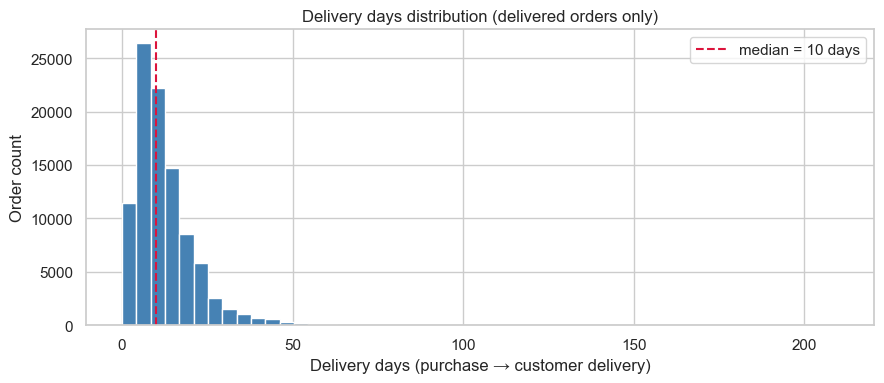

Tail: p90 = 23 days, p95 = 29 days, max = 210 days


In [43]:
# 8a. Delivery-days histogram (delivered orders only)
fig, ax = plt.subplots(figsize=(9, 4))

delivery_days = delivered["delivery_days"].dropna()
ax.hist(delivery_days, bins=50, color="steelblue", edgecolor="white")
median_days = delivery_days.median()
p90_days = delivery_days.quantile(0.90)
p95_days = delivery_days.quantile(0.95)

ax.axvline(median_days, color="crimson", ls="--", lw=1.5, label=f"median = {median_days:.0f} days")
ax.set_xlabel("Delivery days (purchase → customer delivery)")
ax.set_ylabel("Order count")
ax.set_title("Delivery days distribution (delivered orders only)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Tail: p90 = {p90_days:.0f} days, p95 = {p95_days:.0f} days, max = {delivery_days.max():.0f} days")

In [44]:
# 8b. On-time rate by customer_state (states with n >= 100)
state_summary = con.sql("""
    SELECT
        customer_state,
        COUNT(*) AS n_orders,
        SUM(is_delivered::INT) AS n_delivered,
        ROUND(AVG(CASE WHEN is_delivered THEN on_time END), 4) AS on_time_rate
    FROM orders_analytical
    GROUP BY 1
    HAVING COUNT(*) >= 100
    ORDER BY n_orders DESC
""").df()

median_rate = state_summary["on_time_rate"].median()
state_summary["vs_median"] = state_summary["on_time_rate"].apply(
    lambda r: "above" if r >= median_rate else "below"
)

print(f"Median on-time rate across states (n≥100): {median_rate:.1%}\n")
state_summary.head(15)

Median on-time rate across states (n≥100): 90.3%



,customer_state,n_orders,n_delivered,on_time_rate,vs_median
0,SP,41746,40501.0,0.9551,above
1,RJ,12852,12350.0,0.8789,below
2,MG,11635,11354.0,0.9543,above
3,RS,5466,5345.0,0.9392,above
4,PR,5045,4923.0,0.9596,above
5,SC,3637,3546.0,0.9179,above
6,BA,3380,3256.0,0.8784,below
7,DF,2140,2080.0,0.9433,above
8,ES,2033,1995.0,0.8927,below
9,GO,2020,1957.0,0.9346,above


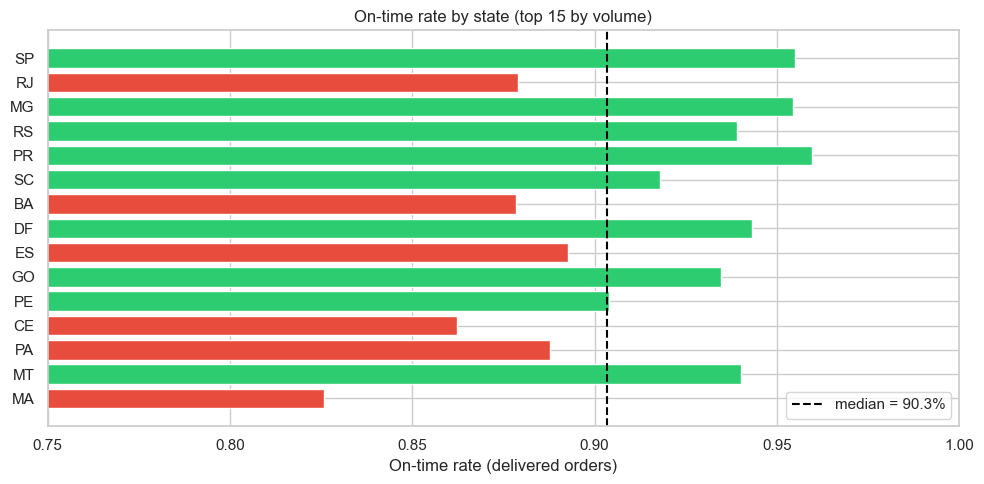

In [45]:
top_states = state_summary.head(15).iloc[::-1]
colors = ["#2ecc71" if r >= median_rate else "#e74c3c" for r in top_states["on_time_rate"]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_states["customer_state"], top_states["on_time_rate"], color=colors)
ax.axvline(median_rate, color="black", ls="--", lw=1.5, label=f"median = {median_rate:.1%}")
ax.set_xlabel("On-time rate (delivered orders)")
ax.set_title("On-time rate by state (top 15 by volume)")
ax.set_xlim(0.75, 1.0)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

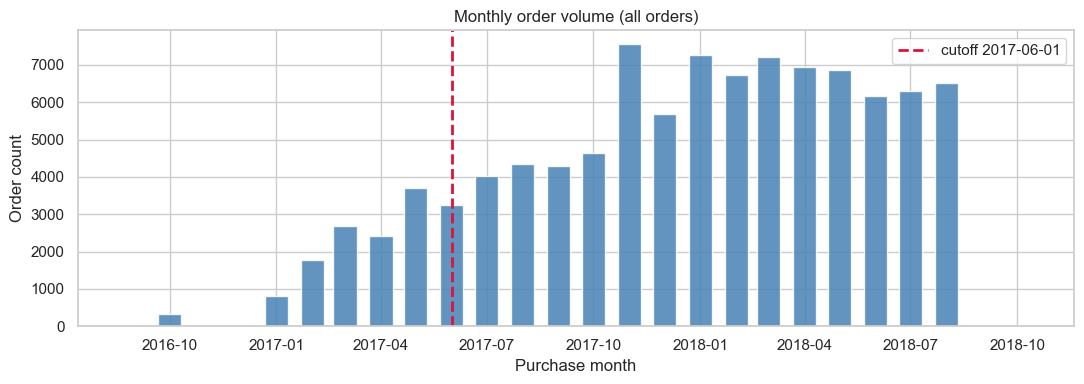

Pre-cutoff months: 8 | orders: 11,695
Post-cutoff months: 17 | orders: 87,746


In [ ]:
# 8c. Monthly order volume + cutoff line
monthly = con.sql("""
    SELECT purchase_month, COUNT(*) AS n_orders
    FROM orders_analytical
    GROUP BY 1
    ORDER BY 1
""").df()
monthly["purchase_month"] = pd.to_datetime(monthly["purchase_month"])

pre_months = monthly[monthly["purchase_month"] < CUTOFF]
post_months = monthly[monthly["purchase_month"] >= CUTOFF]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(monthly["purchase_month"], monthly["n_orders"], width=20, color="steelblue", alpha=0.85)
ax.axvline(pd.Timestamp(CUTOFF), color="crimson", ls="--", lw=2, label=f"cutoff {CUTOFF}")
ax.set_xlabel("Purchase month")
ax.set_ylabel("Order count")
ax.set_title("Monthly order volume (all orders)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Pre-cutoff months: {len(pre_months)} | orders: {pre_months['n_orders'].sum():,}")
print(f"Post-cutoff months: {len(post_months)} | orders: {post_months['n_orders'].sum():,}")

In [47]:
# 8d. Candidate treated states — volume and pre/post split
candidate_states = con.sql(f"""
    SELECT
        customer_state,
        COUNT(*) AS n_orders,
        SUM(CASE WHEN purchase_date < DATE '{CUTOFF}' THEN 1 ELSE 0 END) AS n_pre,
        SUM(CASE WHEN purchase_date >= DATE '{CUTOFF}' THEN 1 ELSE 0 END) AS n_post,
        ROUND(AVG(CASE WHEN is_delivered THEN on_time END), 4) AS on_time_rate
    FROM orders_analytical
    WHERE customer_state IN ('SP', 'RJ', 'MG')
    GROUP BY 1
    ORDER BY n_orders DESC
""").df()

candidate_states

,customer_state,n_orders,n_pre,n_post,on_time_rate
0,SP,41746,4411.0,37335.0,0.9551
1,RJ,12852,1628.0,11224.0,0.8789
2,MG,11635,1468.0,10167.0,0.9543


#### So what — can DiD work here?

**Outcome sanity**
- Delivered orders are ~97% of the mart; `on_time` among delivered is ~93% platform-wide.
- Delivery days are right-skewed (median ~10 days; p90 ~23 days). Long tail orders exist but are a small share.

**Regional volume (treatment candidates)**
- **SP**, **RJ**, and **MG** are the top 3 states by order volume — plausible treated regions for a simulated high-demand rollout.
- All three have thousands of pre-cutoff orders (not zero), but pre-period volume is much smaller than post-period because Olist scaled rapidly after mid-2017.

**Time coverage**
- Data spans **Sep 2016 – Oct 2018**.
- Pre-cutoff window is **~8 months** (not a full 12). DiD is still feasible, but parallel trends must be checked on **weekly** pre-period series and interpreted cautiously.

**Balance preview (Week 2 task)**
- SP and MG have higher baseline on-time (~95%) than RJ (~88%). DiD does **not** require equal levels pre-treatment, but RJ vs other treated states may need explicit discussion in the balance table.

**Week 2 decision (provisional)**
- Treated states: `SP`, `RJ`, `MG`
- Cutoff: `2017-06-01`
- Control: all other `customer_state` values
- Primary outcome: `on_time` among delivered orders

> Re-run the cells above after any mart change. Week 1 is complete when plots render and this interpretation still holds.